## save

In [2]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

LIMIT = 100

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=LIMIT,
    # limit to 10:
    lazy=False
)

In [3]:
rows = []
for run in runs[:LIMIT]:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "train_accuracy": summary.get("train_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
        'tags': attrs.get("tags", []),
        'input_dim': params.get("input_dim"),
    })
df = pd.DataFrame(rows)
df["task_name"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df['created_at'] = pd.to_datetime(df['created_at'])
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df['trained_on_display_name'] = df.pretrained_model_run.str.findall("(.+)/(.+)/((checkpoint/(.+)\.ckpt)|state_dict)$").str[0].str[1]
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
mask = df['trained_on_display_name'].isin(df['display_name'])
existing_trained_on_display_names = df.trained_on_display_name[mask]
df__ = df.copy()

In [4]:
exp_df = df__[df__.display_name.str.contains("(interaction|retweet)(.*)250k")]
exp_df['graph_type'] = exp_df.display_name.str.findall("(interaction|retweet)(.*)250k").str[0].str[0]
exp_df['input_feature_type'] = exp_df.display_name.str.findall("(interaction|retweet)(.*)250k_(all|constant1|stats_only|emb_only|minilm)").str[0].str[-1].fillna('all')

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_66088/1837453224.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  exp_df = df__[df__.display_name.str.contains("(interaction|retweet)(.*)250k")]


In [5]:
exp_df.to_csv("exp_df.csv")

## process

In [7]:
exp_df = pd.read_csv("exp_df.csv")

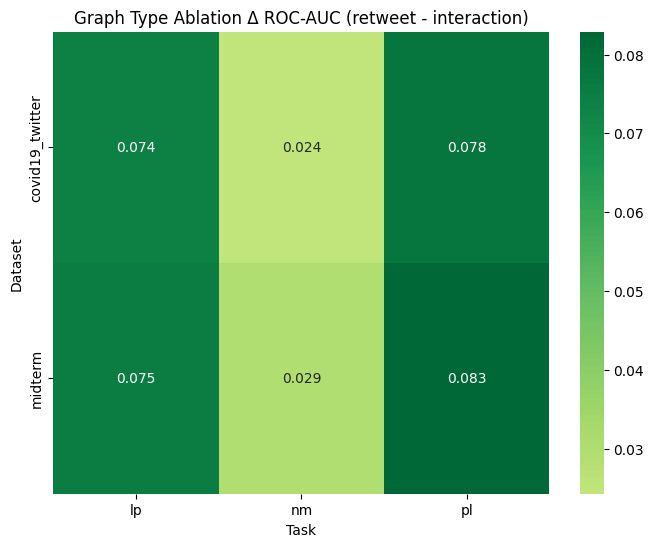

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# average in case multiple runs exist
graph_ablation = (
    exp_df.groupby(["dataset", "task_name", "graph_type"])["test_roc_auc"]
    .mean()
    .reset_index()
)

# make graph types columns
pivot = graph_ablation.pivot_table(
    index=["dataset", "task_name"],
    columns="graph_type",
    values="test_roc_auc"
)

# compute delta
# adjust names if your graph types differ
pivot["delta"] = pivot["retweet"] - pivot["interaction"]

# reshape for heatmap
delta_heatmap = pivot["delta"].unstack("task_name")

plt.figure(figsize=(8,6))
sns.heatmap(
    delta_heatmap,
    annot=True,
    cmap="RdYlGn",
    # vmin=0, vmax=0.2,
    center=0,     # important: zero becomes neutral
    fmt=".3f"
)

plt.title("Graph Type Ablation Δ ROC-AUC (retweet - interaction)")
plt.ylabel("Dataset")
plt.xlabel("Task")
plt.show()

<Figure size 1000x600 with 0 Axes>

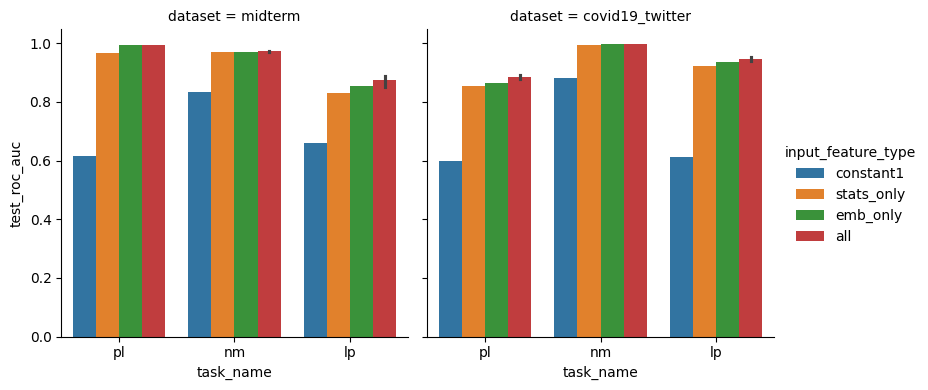

In [9]:
plt.figure(figsize=(10,6))
exp_df['input_feature_type_order'] = exp_df.input_feature_type.map({'constant1':0, 'stats_only':1, 'emb_only':2, 'all': 3})
exp_df = exp_df.sort_values('input_feature_type_order')
sns.catplot(
    data=exp_df,
    x="task_name",
    y="test_roc_auc",
    hue="input_feature_type",
    col="dataset",
    kind="bar",
    height=4,
    aspect=1
)
# plt.title("Input Feature Ablation")
plt.show()